# Mortality maps on MDP states — dataset, tabular MDP, and pretrained baselines

This notebook compares **in-hospital mortality risk as a function of discrete MDP cluster state**:

1. **Ground truth (cohort)**  
   - **Patient-level:** for each transient state \(s\), average outcome over **distinct ICU stays** that visit \(s\) at least once (one label per stay).  
   - **Row-level (RL rows):** same as `icu_sepsis_demo.ipynb` §9 — mean outcome over all RL-table rows with `state == s` (weights frequent stays more).
2. **Tabular MDP**  
   - **Closed form:** absorption probability into the death state under the **optimal** policy (same linear system as §9 expert, but with \(\pi^\*\) from value iteration).  
   - **Monte Carlo:** independent rollouts under \(\pi^\*\) from each start state (sanity check vs closed form).
3. **Pretrained mortality models** from `COPERvsTRANSFORMER_mortality.ipynb`  
   - **Deep:** exported `.pt` bundles (`COPER` / `TRANSFORMER`, 1-NODE / 2-NODE) — forward pass on a **representative sequence** per state.  
   - **Classical:** logistic (L2/L1), random forest, LSTM — `predict_proba` / logits on the **same** representative tensors (flattened where needed).

**Representative input per state:** among all mortality-pickle patients with complete 48-bloc MDP labelling, take **mean** of their `X` tensors over everyone who ever occupies state \(s\) in `per_bloc_state_matrix` (same join as `data_mngmt/contracts/coper_mdp_join.py`).

**Prerequisites:** unified MDP build (`mdp_params_<slug>/`), cohort CSV, mortality pickle aligned with that slug; run `COPERvsTRANSFORMER_mortality.ipynb` to export bundles and fit sklearn/LSTM baselines.

**Configure** `UNIFIED_BUILD_SLUG`, `NITERS`, `DROP_TAG`, and optionally `LIMIT_DEEP_MODELS` in the next section.

### Reading the printed sanity checks

- **Optimal policy — mean \|MC − closed\|:** With finitely many rollouts per state (e.g. 300), a mean absolute error around **0.005–0.02** on transient states is normal; a max around **~0.05** can happen. Increase `N_ROLLOUTS_OPT_MC` to tighten the check.
- **`metadata.json` lists 750 clusters but the env has fewer states (e.g. 723):** K-means targets **750** prototypes; **transient states with no incoming mass are pruned** when building the MDP. The Gym `N_STATES` is **after** pruning; **transient count = `N_STATES − 3`** (death, survival, `s_inf`). You will not see 750 transient IDs.
- **`valid MDP alignment` ≪ pickle rows:** `per_bloc_state_matrix` requires **every** bloc `1…T` with a cluster id in `[0, n_transient)`. Many stays lack a complete RL path or fail the join, so only a **subset** of pickle rows is valid; the count of states with at least one aligned patient is often **below** `n_transient`.

### Similarity table: what each **method** is
The metrics below compare each method’s **mortality map** (one scalar per transient MDP state) to the **reference** map **`mortality_patient`**: mean in-hospital death label over **distinct ICU stays** that visit that state at least once. Rows are filtered to states with enough patients (`MIN_PATIENTS_PER_STATE`).
| Method prefix | Meaning |
|---------------|---------|
| **`mortality_patient`** | Reference (not a row in `sim_df`). Patient-level empirical mortality by state. |
| **`mortality_row`** | Empirical mortality by state averaging **every RL-table row** with that cluster label (same weighting as `icu_sepsis_demo` §9); often closer to `mortality_patient` than models because both describe the cohort. |
| **`mort_mdp_opt_closed`** | **Tabular MDP**, **optimal** policy \(\pi^\*\) from value iteration: **closed-form** probability of eventually hitting the **death** absorbing state starting from \(s\). |
| **`mort_mdp_opt_mc`** | Same as above, but **Monte Carlo** rollouts under \(\pi^\*\) (finite-sample estimate of the same quantity). |
| **`deep:…`** | **Exported** COPER or Transformer bundle from `COPERvsTRANSFORMER_mortality.ipynb`: mortality **sigmoid output** on the **mean MIMIC tensor** over pickle patients that align with that MDP state (48-bloc path). Stem encodes architecture, `drop*`, seed, epochs. |
| **`sklearn:logistic_l1` / `logistic_l2`** | **Flattened** (48×76) **logistic regression** baseline trained on the same mortality pickle; `predict_proba` on the same per-state mean tensor. |
| **`sklearn:random_forest`** | **Random forest** on flattened sequences, same setup. |
| **`torch:lstm`** | Small **PyTorch LSTM** baseline saved as `mortality_lstm.pt`; logits → sigmoid on the **sequence** tensor per state. |


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import gymnasium as gym
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from tqdm.auto import tqdm


def _find_coper_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(14):
        if (p / "icu_sepsis" / "icu_sepsis").is_dir() and (p / "data_mngmt").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(f"Could not find COPER repo root from {start}")


REPO = _find_coper_root(Path.cwd())
for pkg in (REPO, REPO / "icu_sepsis" / "icu_sepsis", REPO / "icu_sepsis" / "icu_sepsis_helpers"):
    s = str(pkg)
    if s not in sys.path:
        sys.path.insert(0, s)

import icu_sepsis  # noqa: E402
from data_mngmt import mortality_pickle_path  # noqa: E402
from data_mngmt.contracts.coper_mdp_join import (  # noqa: E402
    cohort_csv_with_mdp_states,
    default_unified_cohort_paths,
    per_bloc_state_matrix,
)
from icu_sepsis.utils.io import MDPParameters  # noqa: E402
from icu_sepsis_helpers.utils.mdp import value_iteration  # noqa: E402
from utils.embedding_data_utils import load_icustay_ids_split, load_xy_split  # noqa: E402
from utils.lstm import _MortalityLSTM  # noqa: E402
from utils.load_coper_bundle import load_coper_from_bundle  # noqa: E402
from utils.results_layout import notebook_demo_dir  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO", REPO)
print("DEVICE", DEVICE)

# ---- Align with your unified build + training exports ----
UNIFIED_BUILD_SLUG = "sepsis-60m-h48ihm"
USE_PACKAGED_MDP = False
NITERS = 10
DROP_TAG = "drop0"
SEED_TAG = "s1"
N_ROLLOUTS_OPT_MC = 300
MIN_PATIENTS_PER_STATE = 5
LIMIT_DEEP_MODELS: int | None = None  # e.g. 4 to debug; None = all matching stems

MORTALITY_PICKLE = mortality_pickle_path()
cohort_csv, mdp_params_dir = default_unified_cohort_paths(REPO, slug=UNIFIED_BUILD_SLUG)
BASELINES_MODELS_DIR = notebook_demo_dir("models", "coper_vs_transformer_mortality", REPO)

marker = REPO / "results" / "latest_mimic_compare_models_dir.txt"
if marker.is_file():
    MODELS_DIR = Path(marker.read_text(encoding="utf-8").strip())
else:
    runs = REPO / "results" / "runs"
    cand = sorted(runs.glob("*_mimic_compare/models"), key=lambda p: p.stat().st_mtime, reverse=True)
    MODELS_DIR = cand[0] if cand else (REPO / "results" / "models")

print("cohort_csv", cohort_csv)
print("mdp_params_dir", mdp_params_dir)
print("MORTALITY_PICKLE", MORTALITY_PICKLE)
print("MODELS_DIR", MODELS_DIR)
print("BASELINES_MODELS_DIR", BASELINES_MODELS_DIR)

REPO /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
DEVICE cuda
cohort_csv /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv
mdp_params_dir /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_params_sepsis-60m-h48ihm
MORTALITY_PICKLE /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data
MODELS_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/runs/2026-04-10_mimic_compare/models
BASELINES_MODELS_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/models


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
ENV_ID = "Sepsis/ICU-Sepsis-v2"
if USE_PACKAGED_MDP:
    env = gym.make(ENV_ID)
else:
    if not (mdp_params_dir / "dynamics.npz").is_file():
        raise FileNotFoundError(mdp_params_dir)
    env = gym.make(ENV_ID, params=MDPParameters(mdp_params_dir))

mdp = env.unwrapped
N_STATES = mdp.num_states
STATE_DEATH = mdp.state_death
STATE_SURVIVAL = mdp.state_survival
STATE_S_INF = mdp.state_s_inf
n_transient = N_STATES - 3

dyn = mdp.dynamics
tx = np.asarray(dyn["tx_mat"], dtype=np.float64)
r_mat = np.asarray(dyn["r_mat"], dtype=np.float64)
expert_pi = np.asarray(mdp.expert_policy, dtype=np.float64)
gamma = float(mdp.gamma)

pi_star, V_star = value_iteration(tx, r_mat, gamma, max_steps=50_000, delta=1e-6)
pi_star = np.asarray(pi_star).reshape(-1)

print("N_STATES", N_STATES, "n_transient", n_transient, "terminals", STATE_DEATH, STATE_SURVIVAL, STATE_S_INF)

Value Iteration:   1%|▏         | 631/50000 [00:29<38:56, 21.13it/s]

N_STATES 723 n_transient 720 terminals 720 721 722


In [3]:
def induced_state_transition(tx_mat: np.ndarray, policy: np.ndarray) -> np.ndarray:
    S, A, _ = tx_mat.shape
    if policy.ndim == 1:
        pa = np.zeros((S, A), dtype=float)
        pa[np.arange(S), policy.astype(int)] = 1.0
    else:
        pa = np.asarray(policy, dtype=float)
        pa = pa / np.clip(pa.sum(axis=1, keepdims=True), 1e-12, None)
    return np.einsum("sa,san->sn", pa, tx_mat)


def death_prob_closed_form(tx_mat: np.ndarray, policy: np.ndarray, s_death: int, s_surv: int, s_inf: int) -> np.ndarray:
    Ppi = induced_state_transition(tx_mat, policy)
    S = Ppi.shape[0]
    terminals = np.array([s_death, s_surv, s_inf], dtype=int)
    transient = np.array([s for s in range(S) if s not in set(terminals)], dtype=int)
    Q = Ppi[np.ix_(transient, transient)]
    b = Ppi[transient, s_death]
    I = np.eye(Q.shape[0], dtype=float)
    try:
        q = np.linalg.solve(I - Q, b)
    except np.linalg.LinAlgError:
        q = np.linalg.lstsq(I - Q, b, rcond=None)[0]
    out = np.zeros(S, dtype=float)
    out[transient] = np.clip(q, 0.0, 1.0)
    out[s_death] = 1.0
    out[s_surv] = 0.0
    out[s_inf] = 0.0
    return out


def death_prob_mc_per_state(
    tx_mat: np.ndarray,
    policy: np.ndarray,
    s_death: int,
    s_surv: int,
    s_inf: int,
    *,
    n_rollouts_per_state: int = 200,
    max_steps: int = 400,
    seed: int = 0,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    S, A, _ = tx_mat.shape
    if policy.ndim == 1:
        pa = np.zeros((S, A), dtype=float)
        pa[np.arange(S), policy.astype(int)] = 1.0
    else:
        pa = np.asarray(policy, dtype=float)
        pa = pa / np.clip(pa.sum(axis=1, keepdims=True), 1e-12, None)
    terminals = {int(s_death), int(s_surv), int(s_inf)}
    out = np.zeros(S, dtype=float)
    for s0 in range(S):
        if s0 in terminals:
            out[s0] = 1.0 if s0 == int(s_death) else 0.0
            continue
        deaths = 0
        for _ in range(n_rollouts_per_state):
            s = int(s0)
            for _t in range(max_steps):
                if s in terminals:
                    break
                a = int(rng.choice(A, p=pa[s]))
                s = int(rng.choice(S, p=tx_mat[s, a]))
            if s == int(s_death):
                deaths += 1
        out[s0] = deaths / max(1, n_rollouts_per_state)
    return out


mort_opt_cf = death_prob_closed_form(tx, pi_star, STATE_DEATH, STATE_SURVIVAL, STATE_S_INF)
mort_opt_mc = death_prob_mc_per_state(
    tx,
    pi_star,
    STATE_DEATH,
    STATE_SURVIVAL,
    STATE_S_INF,
    n_rollouts_per_state=N_ROLLOUTS_OPT_MC,
    max_steps=400,
    seed=11,
)

# Expert-policy counterparts (for policy-mismatch diagnosis vs clinical maps)
mort_expert_cf = death_prob_closed_form(tx, expert_pi, STATE_DEATH, STATE_SURVIVAL, STATE_S_INF)
mort_expert_mc = death_prob_mc_per_state(
    tx,
    expert_pi,
    STATE_DEATH,
    STATE_SURVIVAL,
    STATE_S_INF,
    n_rollouts_per_state=N_ROLLOUTS_OPT_MC,
    max_steps=400,
    seed=13,
)

mc_vs_cf_opt = np.abs(mort_opt_mc[:n_transient] - mort_opt_cf[:n_transient])
mc_vs_cf_exp = np.abs(mort_expert_mc[:n_transient] - mort_expert_cf[:n_transient])
print(
    "Optimal policy: mean |MC - closed| on transient states:",
    float(np.nanmean(mc_vs_cf_opt)),
    "max",
    float(np.nanmax(mc_vs_cf_opt)),
)
print(
    "Expert policy: mean |MC - closed| on transient states:",
    float(np.nanmean(mc_vs_cf_exp)),
    "max",
    float(np.nanmax(mc_vs_cf_exp)),
)

Optimal policy: mean |MC - closed| on transient states: 0.00690324624546137 max 0.05524320729928178
Expert policy: mean |MC - closed| on transient states: 0.016291289948522438 max 0.07367865342103833


In [4]:
raw_cohort = pd.read_csv(cohort_csv)
outcome_col = next(
    (c for c in ("mortality_inhospital", "died_in_hosp", "mortality_90d", "outcome_y") if c in raw_cohort.columns),
    None,
)
if outcome_col is None:
    raise KeyError(f"No mortality column in {cohort_csv}")

n_act = int(round(np.sqrt(mdp.env_metadata["n_actions"])))
cohort_with_states = cohort_csv_with_mdp_states(
    cohort_csv=cohort_csv,
    n_states=n_transient,
    n_action_levels=n_act,
    seed=0,
    outcome_column=outcome_col,
)
outcome_rl_col = outcome_col if outcome_col in cohort_with_states.columns else "outcome_y"
icu_col = next(c for c in ("icustayid", "ICUSTAY_ID", "icustay_id") if c in cohort_with_states.columns)

state_stats_rows = (
    cohort_with_states[["state", outcome_rl_col]]
    .assign(**{outcome_rl_col: pd.to_numeric(cohort_with_states[outcome_rl_col], errors="coerce")})
    .dropna(subset=["state", outcome_rl_col])
)
g_rows = (
    state_stats_rows.groupby("state", as_index=False)
    .agg(n_rows=(outcome_rl_col, "size"), mortality_row=(outcome_rl_col, "mean"))
    .sort_values("state")
)

stay_outcome = cohort_with_states[[icu_col, outcome_rl_col]].copy()
stay_outcome[outcome_rl_col] = pd.to_numeric(stay_outcome[outcome_rl_col], errors="coerce")
stay_outcome = stay_outcome.drop_duplicates(subset=[icu_col]).dropna()
stay_y = stay_outcome.set_index(icu_col)[outcome_rl_col].astype(float)
rows_pat = []
for s in range(n_transient):
    icu_vis = cohort_with_states.loc[pd.to_numeric(cohort_with_states["state"], errors="coerce") == s, icu_col].unique()
    ys = stay_y.reindex(icu_vis).dropna()
    rows_pat.append({"state": s, "n_patients": int(len(ys)), "mortality_patient": float(ys.mean()) if len(ys) else np.nan})
g_pat = pd.DataFrame(rows_pat)

cmp = g_pat.merge(g_rows, on="state", how="outer").sort_values("state")
cmp["mort_mdp_opt_closed"] = cmp["state"].map(lambda s: mort_opt_cf[int(s)] if pd.notna(s) else np.nan)
cmp["mort_mdp_opt_mc"] = cmp["state"].map(lambda s: mort_opt_mc[int(s)] if pd.notna(s) else np.nan)
cmp["mort_mdp_expert_closed"] = cmp["state"].map(lambda s: mort_expert_cf[int(s)] if pd.notna(s) else np.nan)
cmp["mort_mdp_expert_mc"] = cmp["state"].map(lambda s: mort_expert_mc[int(s)] if pd.notna(s) else np.nan)
cmp.head()

,state,n_patients,mortality_patient,n_rows,mortality_row,mort_mdp_opt_closed,mort_mdp_opt_mc,mort_mdp_expert_closed,mort_mdp_expert_mc
0,0,203,0.123153,652,0.125767,0.012756,0.010000,0.148158,0.130000
1,1,10,0.000000,89,0.000000,0.012631,0.010000,0.121513,0.143333
2,2,179,0.145251,702,0.169516,0.011269,0.020000,0.143036,0.153333
3,3,161,0.099379,580,0.143103,0.018452,0.033333,0.140330,0.143333
4,4,72,0.083333,231,0.043290,0.050244,0.066667,0.143151,0.150000


In [5]:
def _concat_splits(pickle_path: Path):
    X_tr, y_tr = load_xy_split(pickle_path, "train")
    X_va, y_va = load_xy_split(pickle_path, "val")
    X_te, y_te = load_xy_split(pickle_path, "test")
    X = np.concatenate([X_tr, X_va, X_te], axis=0).astype(np.float32)
    y = np.concatenate([y_tr, y_va, y_te], axis=0).astype(np.float64)
    icu_tr = load_icustay_ids_split(pickle_path, "train")
    icu_va = load_icustay_ids_split(pickle_path, "val")
    icu_te = load_icustay_ids_split(pickle_path, "test")
    icu = np.concatenate([icu_tr, icu_va, icu_te], axis=0)
    return X, y, icu


X_all, y_all, icu_all = _concat_splits(MORTALITY_PICKLE)
T = X_all.shape[1]
state_mat, valid = per_bloc_state_matrix(
    cohort_with_states,
    icu_all,
    n_blocs=T,
    max_state_exclusive=n_transient,
)
print("Pickle X", X_all.shape, "valid MDP alignment", int(valid.sum()), "/", len(valid))

valid_idx = np.where(valid)[0]
X_valid = X_all[valid_idx]
state_mat_valid = state_mat[valid_idx]

# For each transient state s, keep patient indices and time-weights n_{i,s}
# (number of blocs where patient i is in state s), for time-weighted averaging.
patient_idx_by_state: list[np.ndarray] = []
patient_w_by_state: list[np.ndarray] = []
n_vis = np.zeros(n_transient, dtype=int)
for s in range(n_transient):
    counts = (state_mat_valid == s).sum(axis=1).astype(np.float64)
    idx = np.where(counts > 0)[0]
    patient_idx_by_state.append(idx)
    patient_w_by_state.append(counts[idx])
    n_vis[s] = int(idx.size)

print("States with at least one aligned patient:", int((n_vis > 0).sum()))

Pickle X (4117, 48, 76) valid MDP alignment 1063 / 4117
States with at least one aligned patient: 688


In [6]:
@torch.no_grad()
def deep_predict_proba(model: nn.Module, X_bt: torch.Tensor) -> np.ndarray:
    tp = torch.linspace(0, 1, X_bt.shape[1], device=X_bt.device, dtype=X_bt.dtype)
    out = model(X_bt, [tp], [tp], [tp])
    if out.ndim > 1:
        out = out.squeeze(-1)
    # `COPER` / `TRANSFORMER` already end with `nn.Sigmoid()` on the mortality head.
    return out.detach().cpu().numpy().astype(np.float64)


def aggregate_state_time_weighted(
    values_per_patient: np.ndarray,
    idx_by_state: list[np.ndarray],
    w_by_state: list[np.ndarray],
    n_states: int,
) -> np.ndarray:
    out = np.full(n_states, np.nan, dtype=np.float64)
    for s in range(n_states):
        idx = idx_by_state[s]
        if idx.size == 0:
            continue
        w = np.asarray(w_by_state[s], dtype=np.float64)
        ww = np.clip(w, 0.0, None)
        if ww.sum() <= 0:
            out[s] = float(np.mean(values_per_patient[idx]))
        else:
            out[s] = float(np.average(values_per_patient[idx], weights=ww))
    return out


def discover_deep_stems(models_dir: Path) -> list[str]:
    suf = f"_{DROP_TAG}_{SEED_TAG}_e{NITERS}"
    stems = []
    for p in sorted(models_dir.glob(f"*{suf}.json")):
        stem = p.stem
        if not ("coper" in stem or "transformer" in stem):
            continue
        if not (models_dir / f"{stem}.pt").is_file():
            continue
        stems.append(stem)
    return stems


deep_stems = discover_deep_stems(MODELS_DIR)
if LIMIT_DEEP_MODELS is not None:
    deep_stems = deep_stems[:LIMIT_DEEP_MODELS]
print("Deep stems:", deep_stems)

# Patient-level inference first, then time-weighted mean by MDP state (weights = time spent in state).
deep_cols: dict[str, np.ndarray] = {}
X_valid_t = torch.from_numpy(X_valid).to(DEVICE)
for stem in tqdm(deep_stems, desc="deep models"):
    bundle = MODELS_DIR / f"{stem}.pt"
    model, _meta = load_coper_from_bundle(bundle, REPO, device=DEVICE)
    patient_probs = deep_predict_proba(model, X_valid_t)
    deep_cols[f"deep:{stem}"] = aggregate_state_time_weighted(
        patient_probs,
        patient_idx_by_state,
        patient_w_by_state,
        n_transient,
    )

baseline_probs: dict[str, np.ndarray] = {}
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
for name, fname in [
    ("sklearn:logistic_l2", "mortality_logistic_l2.joblib"),
    ("sklearn:logistic_l1", "mortality_logistic_l1.joblib"),
    ("sklearn:random_forest", "mortality_random_forest.joblib"),
]:
    path = BASELINES_MODELS_DIR / fname
    if not path.is_file():
        print("skip missing", path)
        continue
    est = joblib.load(path)
    patient_probs = est.predict_proba(X_valid_flat)[:, 1].astype(np.float64)
    baseline_probs[name] = aggregate_state_time_weighted(
        patient_probs,
        patient_idx_by_state,
        patient_w_by_state,
        n_transient,
    )

lstm_path = BASELINES_MODELS_DIR / "mortality_lstm.pt"
if lstm_path.is_file():
    payload = torch.load(lstm_path, map_location=DEVICE)
    lstm = _MortalityLSTM(
        int(payload["input_dim"]),
        int(payload["hidden_dim"]),
        int(payload["num_layers"]),
        bool(payload["bidirectional"]),
        float(payload["dropout"]),
    ).to(DEVICE)
    lstm.load_state_dict(payload["state_dict"])
    lstm.eval()
    with torch.no_grad():
        logits = lstm(X_valid_t).reshape(-1)
        patient_probs = torch.sigmoid(logits).detach().cpu().numpy().astype(np.float64)
    baseline_probs["torch:lstm"] = aggregate_state_time_weighted(
        patient_probs,
        patient_idx_by_state,
        patient_w_by_state,
        n_transient,
    )
else:
    print("skip missing LSTM", lstm_path)

for k, v in baseline_probs.items():
    deep_cols[k] = v

Deep stems: ['coper_1node_drop0_s1_e10', 'coper_2node_drop0_s1_e10', 'transformer_2node_drop0_s1_e10', 'transformer_baseline_drop0_s1_e10']


deep models: 100%|██████████| 4/4 [00:00<00:00,  6.36it/s]


,method,n_states,pearson_r,spearman_r,mae,rmse
4,mortality_row,673,0.841214,0.825319,0.078508,0.117297
11,sklearn:random_forest,661,0.695887,0.616665,0.107848,0.138720
9,sklearn:logistic_l2,661,0.602832,0.524429,0.141990,0.196554
10,sklearn:logistic_l1,661,0.572701,0.521652,0.185356,0.223883
12,torch:lstm,661,0.448508,0.446878,0.120579,0.152717
8,deep:transformer_baseline_drop0_s1_e10,661,0.444634,0.425260,0.127713,0.163132
5,deep:coper_1node_drop0_s1_e10,661,0.436198,0.414352,0.122250,0.159494
6,deep:coper_2node_drop0_s1_e10,661,0.431671,0.399423,0.101251,0.142163
7,deep:transformer_2node_drop0_s1_e10,661,0.420359,0.393500,0.106798,0.146262
1,mort_mdp_opt_mc,673,0.006590,0.012310,0.197764,0.252792


,min_patients,method,n_states,pearson_r,spearman_r
0,1,deep:coper_1node_drop0_s1_e10,688,0.412751,0.413203
1,3,deep:coper_1node_drop0_s1_e10,673,0.432147,0.411110
2,5,deep:coper_1node_drop0_s1_e10,661,0.436198,0.414352
3,10,deep:coper_1node_drop0_s1_e10,621,0.476099,0.460753
4,20,deep:coper_1node_drop0_s1_e10,567,0.495343,0.468495
5,1,deep:coper_2node_drop0_s1_e10,688,0.415893,0.401767
6,3,deep:coper_2node_drop0_s1_e10,673,0.426198,0.396791
7,5,deep:coper_2node_drop0_s1_e10,661,0.431671,0.399423
8,10,deep:coper_2node_drop0_s1_e10,621,0.470631,0.443967
9,20,deep:coper_2node_drop0_s1_e10,567,0.489533,0.453012


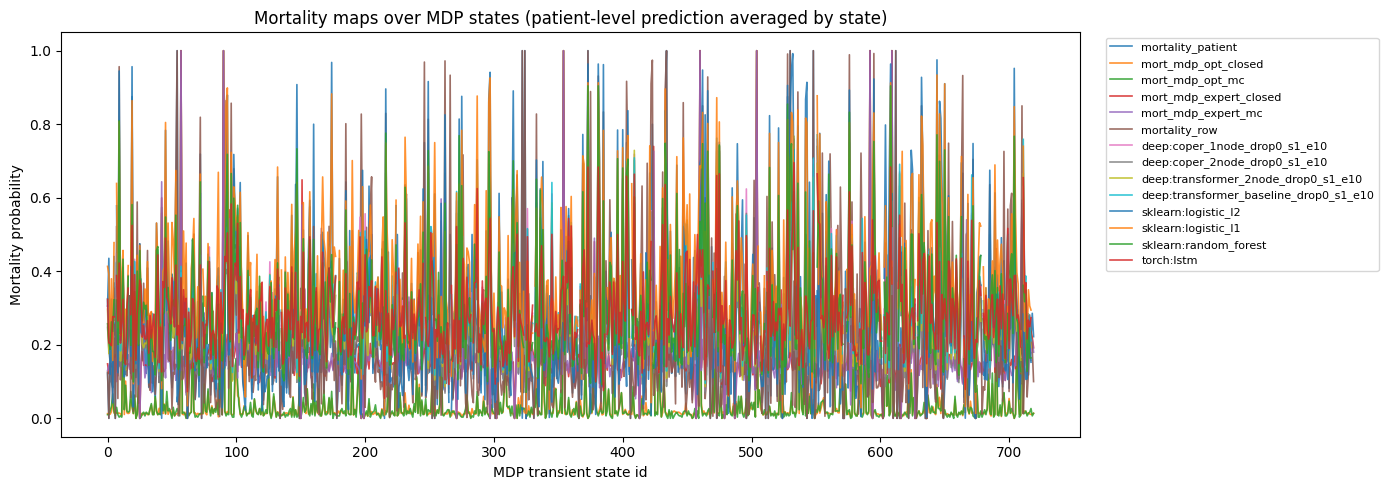

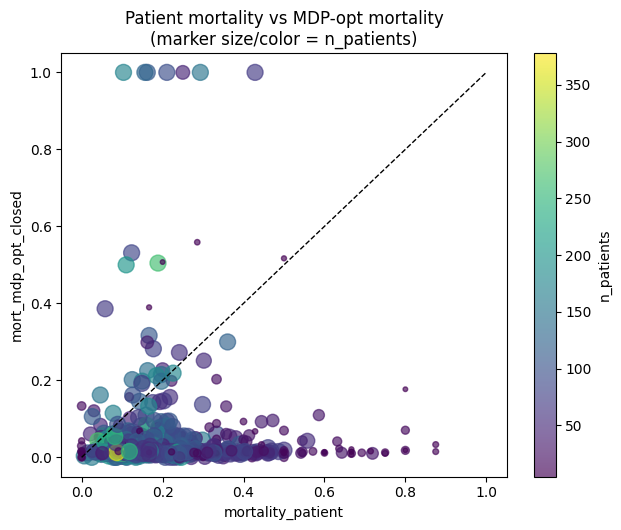

mort_mdp_opt_closed vs mort_mdp_opt_mc: n=720 pearson=0.9962 MAE=0.0069 RMSE=0.0100
mort_mdp_expert_closed vs mort_mdp_expert_mc: n=720 pearson=0.9828 MAE=0.0163 RMSE=0.0210


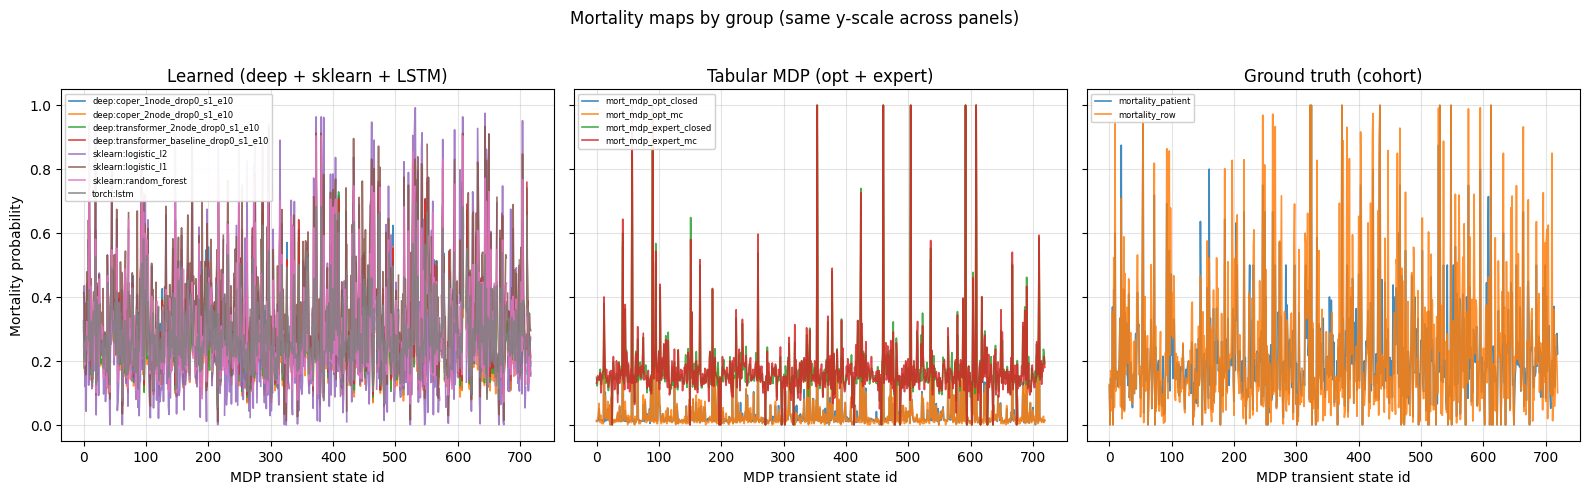

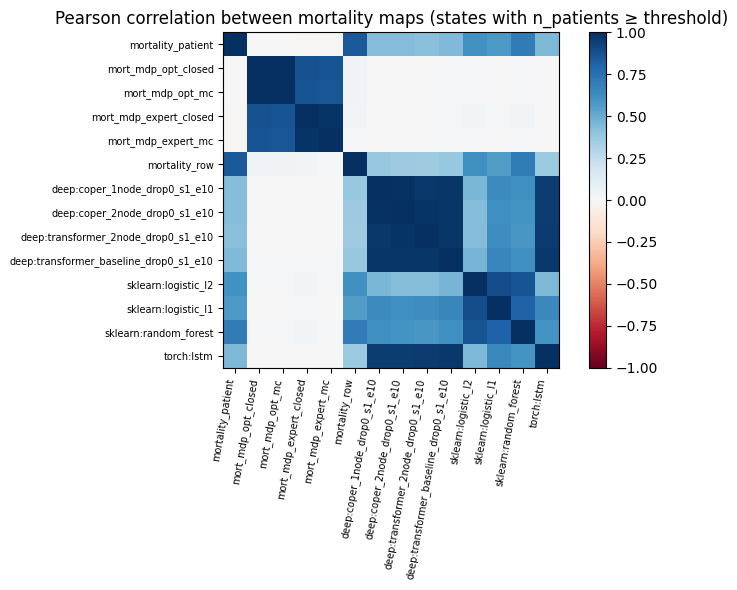

In [7]:
M = pd.DataFrame({"state": np.arange(n_transient)})
M = M.merge(
    cmp[
        [
            "state",
            "mortality_patient",
            "mortality_row",
            "n_patients",
            "n_rows",
            "mort_mdp_opt_closed",
            "mort_mdp_opt_mc",
            "mort_mdp_expert_closed",
            "mort_mdp_expert_mc",
        ]
    ],
    on="state",
    how="left",
)
for k, arr in deep_cols.items():
    M[k] = arr

ref = M["mortality_patient"].to_numpy(dtype=np.float64)
eval_mask = (M["n_patients"].to_numpy() >= MIN_PATIENTS_PER_STATE) & np.isfinite(ref)

rows = []
pred_cols = [c for c in M.columns if c.startswith("deep:") or c.startswith("sklearn:") or c.startswith("torch:")]
for name in [
    "mort_mdp_opt_closed",
    "mort_mdp_opt_mc",
    "mort_mdp_expert_closed",
    "mort_mdp_expert_mc",
    "mortality_row",
] + pred_cols:
    v = M[name].to_numpy(dtype=np.float64)
    m = eval_mask & np.isfinite(v)
    if m.sum() < 3:
        continue
    r, p = stats.pearsonr(ref[m], v[m])
    rs, _ = stats.spearmanr(ref[m], v[m])
    rows.append(
        {
            "method": name,
            "n_states": int(m.sum()),
            "pearson_r": float(r),
            "spearman_r": float(rs),
            "mae": float(np.mean(np.abs(ref[m] - v[m]))),
            "rmse": float(np.sqrt(np.mean((ref[m] - v[m]) ** 2))),
        }
    )
sim_df = pd.DataFrame(rows).sort_values("pearson_r", ascending=False)
display(sim_df)

# Sensitivity to state-coverage filter (n_patients threshold)
threshold_rows = []
threshold_grid = [1, 3, 5, 10, 20]
for thr in threshold_grid:
    mask_thr = (M["n_patients"].to_numpy() >= thr) & np.isfinite(ref)
    for name in ["mort_mdp_opt_closed", "mort_mdp_expert_closed", "mortality_row"] + pred_cols:
        v = M[name].to_numpy(dtype=np.float64)
        m = mask_thr & np.isfinite(v)
        if m.sum() < 3:
            continue
        threshold_rows.append(
            {
                "min_patients": thr,
                "method": name,
                "n_states": int(m.sum()),
                "pearson_r": float(stats.pearsonr(ref[m], v[m])[0]),
                "spearman_r": float(stats.spearmanr(ref[m], v[m])[0]),
            }
        )
filter_sensitivity_df = pd.DataFrame(threshold_rows)
display(filter_sensitivity_df.sort_values(["method", "min_patients"]).reset_index(drop=True))

methods_for_plot = [
    "mortality_patient",
    "mort_mdp_opt_closed",
    "mort_mdp_opt_mc",
    "mort_mdp_expert_closed",
    "mort_mdp_expert_mc",
    "mortality_row",
]
methods_for_plot += [c for c in pred_cols if c in M.columns]
methods_for_plot = [c for c in methods_for_plot if c in M.columns]

fig, ax = plt.subplots(figsize=(14, 5))
x = M["state"].to_numpy()
for col in methods_for_plot:
    ax.plot(x, M[col].to_numpy(), lw=1.2, alpha=0.85, label=col)
ax.set_xlabel("MDP transient state id")
ax.set_ylabel("Mortality probability")
ax.set_title("Mortality maps over MDP states (patient-level prediction averaged by state)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Scatter requested: mortality_patient vs mort_mdp_opt_closed (point size = n_patients)
v_opt = M["mort_mdp_opt_closed"].to_numpy(dtype=np.float64)
ms = eval_mask & np.isfinite(v_opt)
fig_sc, ax_sc = plt.subplots(figsize=(6.4, 5.4))
size = np.clip(M.loc[ms, "n_patients"].to_numpy(dtype=np.float64), 2, 60) * 2.2
ax_sc.scatter(
    ref[ms],
    v_opt[ms],
    s=size,
    alpha=0.65,
    c=M.loc[ms, "n_patients"].to_numpy(dtype=np.float64),
    cmap="viridis",
)
ax_sc.plot([0, 1], [0, 1], "k--", lw=1)
ax_sc.set_xlabel("mortality_patient")
ax_sc.set_ylabel("mort_mdp_opt_closed")
ax_sc.set_title("Patient mortality vs MDP-opt mortality\n(marker size/color = n_patients)")
fig_sc.colorbar(ax_sc.collections[0], ax=ax_sc, label="n_patients")
plt.tight_layout()
plt.show()

# MDP internal consistency checks (opt and expert, closed vs MC)
def _print_pair_consistency(name_a: str, name_b: str):
    a = M[name_a].to_numpy(dtype=np.float64)
    b = M[name_b].to_numpy(dtype=np.float64)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        print(f"{name_a} vs {name_b}: insufficient states")
        return
    r = float(stats.pearsonr(a[m], b[m])[0])
    mae = float(np.mean(np.abs(a[m] - b[m])))
    rmse = float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))
    print(f"{name_a} vs {name_b}: n={int(m.sum())} pearson={r:.4f} MAE={mae:.4f} RMSE={rmse:.4f}")


_print_pair_consistency("mort_mdp_opt_closed", "mort_mdp_opt_mc")
_print_pair_consistency("mort_mdp_expert_closed", "mort_mdp_expert_mc")

# Side-by-side: ground truth | tabular MDP | learned models (shared y-limits)
gt_plot_cols = [c for c in ("mortality_patient", "mortality_row") if c in M.columns]
mdp_plot_cols = [
    c
    for c in ("mort_mdp_opt_closed", "mort_mdp_opt_mc", "mort_mdp_expert_closed", "mort_mdp_expert_mc")
    if c in M.columns
]
learned_plot_cols = [c for c in pred_cols if c in M.columns]


def _ylim_shared_mort_maps(df, cols, mask):
    chunks = []
    for c in cols:
        if c not in df.columns:
            continue
        v = df[c].to_numpy(dtype=np.float64)
        m = mask & np.isfinite(v)
        if m.any():
            chunks.append(v[m])
    if not chunks:
        return 0.0, 1.0
    a = np.concatenate(chunks)
    lo, hi = float(np.min(a)), float(np.max(a))
    pad = 0.05 * (hi - lo + 1e-9)
    return lo - pad, hi + pad


ylim_lo, ylim_hi = _ylim_shared_mort_maps(
    M,
    gt_plot_cols + mdp_plot_cols + learned_plot_cols,
    eval_mask,
)

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
x_states = M["state"].to_numpy()
panel_specs = [
    (learned_plot_cols, "Learned (deep + sklearn + LSTM)"),
    (mdp_plot_cols, "Tabular MDP (opt + expert)"),
    (gt_plot_cols, "Ground truth (cohort)"),
]
for ax_i, (cols_i, title_i) in zip(axes3, panel_specs):
    for col in cols_i:
        ax_i.plot(x_states, M[col].to_numpy(), lw=1.2, alpha=0.85, label=col)
    ax_i.set_xlabel("MDP transient state id")
    ax_i.set_title(title_i)
    ax_i.set_ylim(ylim_lo, ylim_hi)
    ax_i.legend(fontsize=6, loc="upper left", framealpha=0.92)
    ax_i.grid(True, alpha=0.35)
axes3[0].set_ylabel("Mortality probability")
fig3.suptitle("Mortality maps by group (same y-scale across panels)", y=1.02)
plt.tight_layout()
plt.show()

Z = M[methods_for_plot].to_numpy(dtype=np.float64)
ok = np.isfinite(Z).all(axis=1) & eval_mask
C = np.corrcoef(Z[ok].T) if ok.sum() > 2 else np.eye(len(methods_for_plot))
fig2, ax2 = plt.subplots(figsize=(max(8, len(methods_for_plot) * 0.35), max(6, len(methods_for_plot) * 0.35)))
im = ax2.imshow(C, vmin=-1, vmax=1, cmap="RdBu")
ax2.set_xticks(range(len(methods_for_plot)))
ax2.set_yticks(range(len(methods_for_plot)))
ax2.set_xticklabels(methods_for_plot, rotation=80, ha="right", fontsize=7)
ax2.set_yticklabels(methods_for_plot, fontsize=7)
ax2.set_title("Pearson correlation between mortality maps (states with n_patients ≥ threshold)")
fig2.colorbar(im, ax=ax2, fraction=0.046)
plt.tight_layout()
plt.show()

mortality_maps_mdp = M
mortality_maps_similarity = sim_df
mortality_filter_sensitivity = filter_sensitivity_df

**Why optimal MDP maps look uncorrelated with `mortality_patient`:** the MDP curve is **absorption into death under \(\pi^\*\)** in the **fitted** transition model, while `mortality_patient` reflects **historical** outcomes under **clinical/expert-like** behaviour and a different notion of risk. Agreement between them is **not** guaranteed; low Pearson/Spearman here is an **interpretability** signal, not a training bug.